# 01 - Exploratory Data Analysis
## Poland Apartments (Multi-City, Multi-Month) — Sale Listings

Input: `cleaned_data_sale.csv` from `00_Data_Wrangling.ipynb` (190,858 rows, 15 cities, 11 monthly snapshots, Aug 2023–Jun 2024).

This notebook explores:
- Price distribution overall and by city
- Numeric feature relationships with price
- Categorical/binary feature effects
- Temporal price trends (new vs. the old single-snapshot project)
- Correlation structure ahead of feature engineering in Notebook 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

data_dir = '../flats-data/'
df = pd.read_csv(data_dir + 'cleaned_data_sale.csv')
print(df.shape)
df.head()

(190858, 27)


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,snapshot_month
0,f8524536d4b09a0c8ccc0197ec9d7bde,szczecin,blockOfFlats,63.00,3.0,4.0,10.0,1980.0,6.53,9.0,0.118,1.389,0.628,0.105,1.652,NaN,0.413,condominium,concreteSlab,unknown,True,True,True,False,True,415000,2023-08
1,accbe77d4b360fea9735f138a50608dd,szczecin,blockOfFlats,36.00,2.0,8.0,10.0,NaN,2.15,16.0,0.273,0.492,0.652,0.291,0.348,1.404,0.205,cooperative,concreteSlab,unknown,False,True,True,False,True,395995,2023-08
2,8373aa373dbc3fe7ca3b7434166b8766,szczecin,tenement,73.02,3.0,2.0,3.0,NaN,3.24,9.0,0.275,0.672,0.367,0.246,0.300,1.857,0.280,condominium,brick,unknown,False,False,False,False,False,565000,2023-08
3,0a68cd14c44ec5140143ece75d739535,szczecin,tenement,87.60,3.0,2.0,3.0,NaN,2.27,32.0,0.175,0.259,0.223,0.359,0.101,0.310,0.087,condominium,brick,unknown,True,True,False,False,True,640000,2023-08
4,f66320e153c2441edc0fe293b54c8aeb,szczecin,blockOfFlats,66.00,3.0,1.0,3.0,NaN,4.07,1.0,0.218,1.690,0.504,0.704,0.501,2.138,0.514,condominium,unknown,unknown,False,False,False,False,False,759000,2023-08


## 1. Price distribution

count    1.908580e+05
mean     7.840009e+05
std      4.105612e+05
min      1.500000e+05
25%      5.200000e+05
50%      6.980000e+05
75%      9.300000e+05
max      3.250000e+06
Name: price, dtype: float64


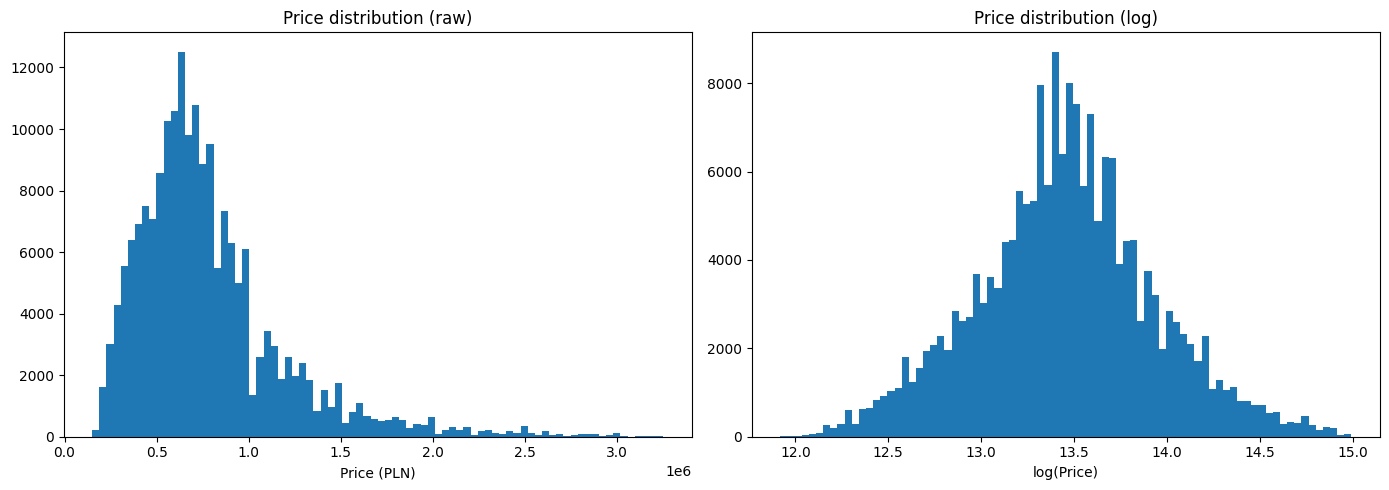

In [2]:
print(df['price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price'], bins=80)
axes[0].set_title('Price distribution (raw)')
axes[0].set_xlabel('Price (PLN)')

axes[1].hist(np.log1p(df['price']), bins=80)
axes[1].set_title('Price distribution (log)')
axes[1].set_xlabel('log(Price)')
plt.tight_layout()
plt.savefig('img/price_distribution.png', dpi=100)
plt.show()

**Note:** price is right-skewed as expected for real estate; log transform (used later for `Log Price` or `Log Area` style features, and for MSLE evaluation) normalizes this substantially.

## 2. Price by city — the core multi-city question

               median          mean  count
city                                      
warszawa     885000.0  1.022711e+06  57946
krakow       795000.0  8.992431e+05  28109
gdansk       749000.0  8.394985e+05  18691
gdynia       696000.0  8.215998e+05   7935
wroclaw      685000.0  7.316132e+05  19728
poznan       599000.0  6.385438e+05   7466
rzeszow      540000.0  5.620068e+05   1790
lublin       530000.0  5.547293e+05   5561
szczecin     519000.0  5.502194e+05   6224
katowice     459000.0  5.017276e+05   5116
bialystok    450000.0  4.773331e+05   2450
lodz         395000.0  4.363195e+05  15011
bydgoszcz    379000.0  4.207178e+05   9404
radom        340000.0  3.583315e+05   2838
czestochowa  320000.0  3.508039e+05   2589


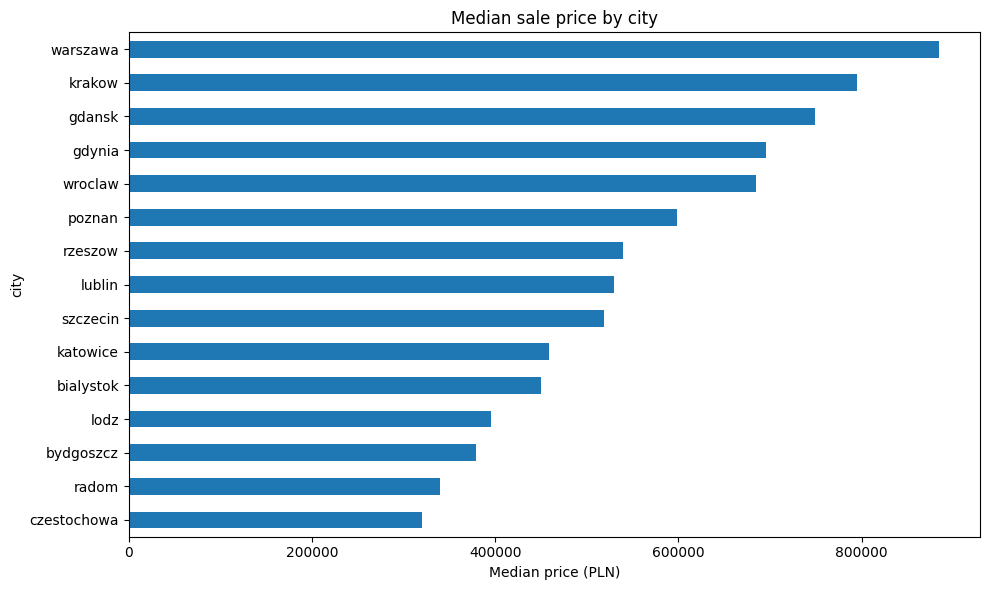

In [3]:
city_price = df.groupby('city')['price'].agg(['median', 'mean', 'count']).sort_values('median', ascending=False)
print(city_price)

fig, ax = plt.subplots(figsize=(10, 6))
city_price['median'].plot(kind='barh', ax=ax)
ax.set_xlabel('Median price (PLN)')
ax.set_title('Median sale price by city')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('img/price_by_city.png', dpi=100)
plt.show()

## 3. Price per square meter by city (normalizes for apartment size differences)

city
warszawa       16900.000000
krakow         15341.905319
gdansk         13439.090093
wroclaw        12408.269569
gdynia         11920.529801
poznan         10547.169811
rzeszow        10000.000000
lublin          9185.632026
bialystok       8942.097154
szczecin        8578.715685
lodz            7962.962963
katowice        7887.096774
bydgoszcz       7550.563323
czestochowa     6390.243902
radom           6336.053989
Name: price_per_sqm, dtype: float64


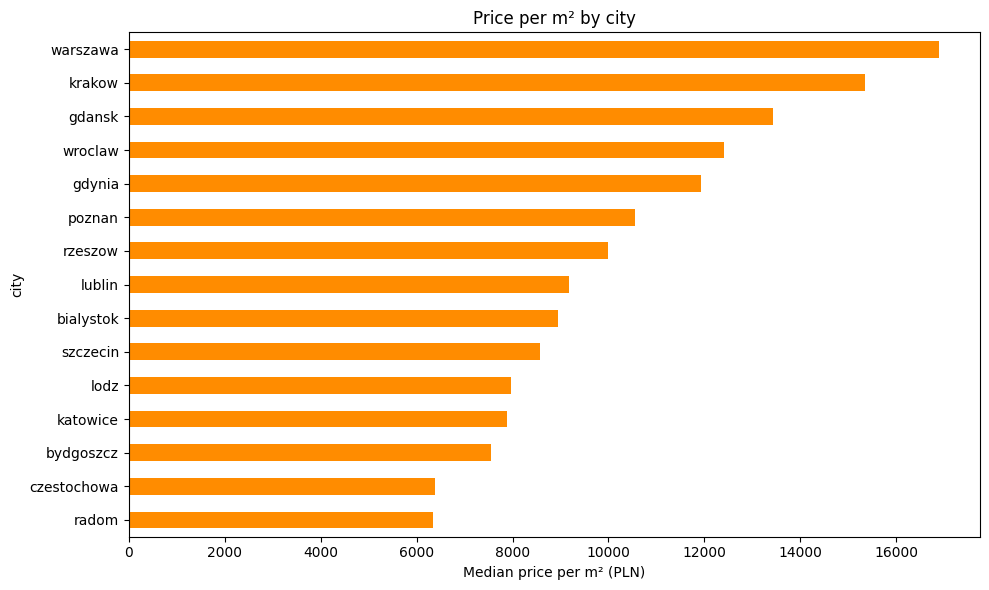

In [4]:
df['price_per_sqm'] = df['price'] / df['squareMeters']

pps_city = df.groupby('city')['price_per_sqm'].median().sort_values(ascending=False)
print(pps_city)

fig, ax = plt.subplots(figsize=(10, 6))
pps_city.plot(kind='barh', ax=ax, color='darkorange')
ax.set_xlabel('Median price per m² (PLN)')
ax.set_title('Price per m² by city')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('img/price_per_sqm_by_city.png', dpi=100)
plt.show()

## 4. Numeric features vs. price

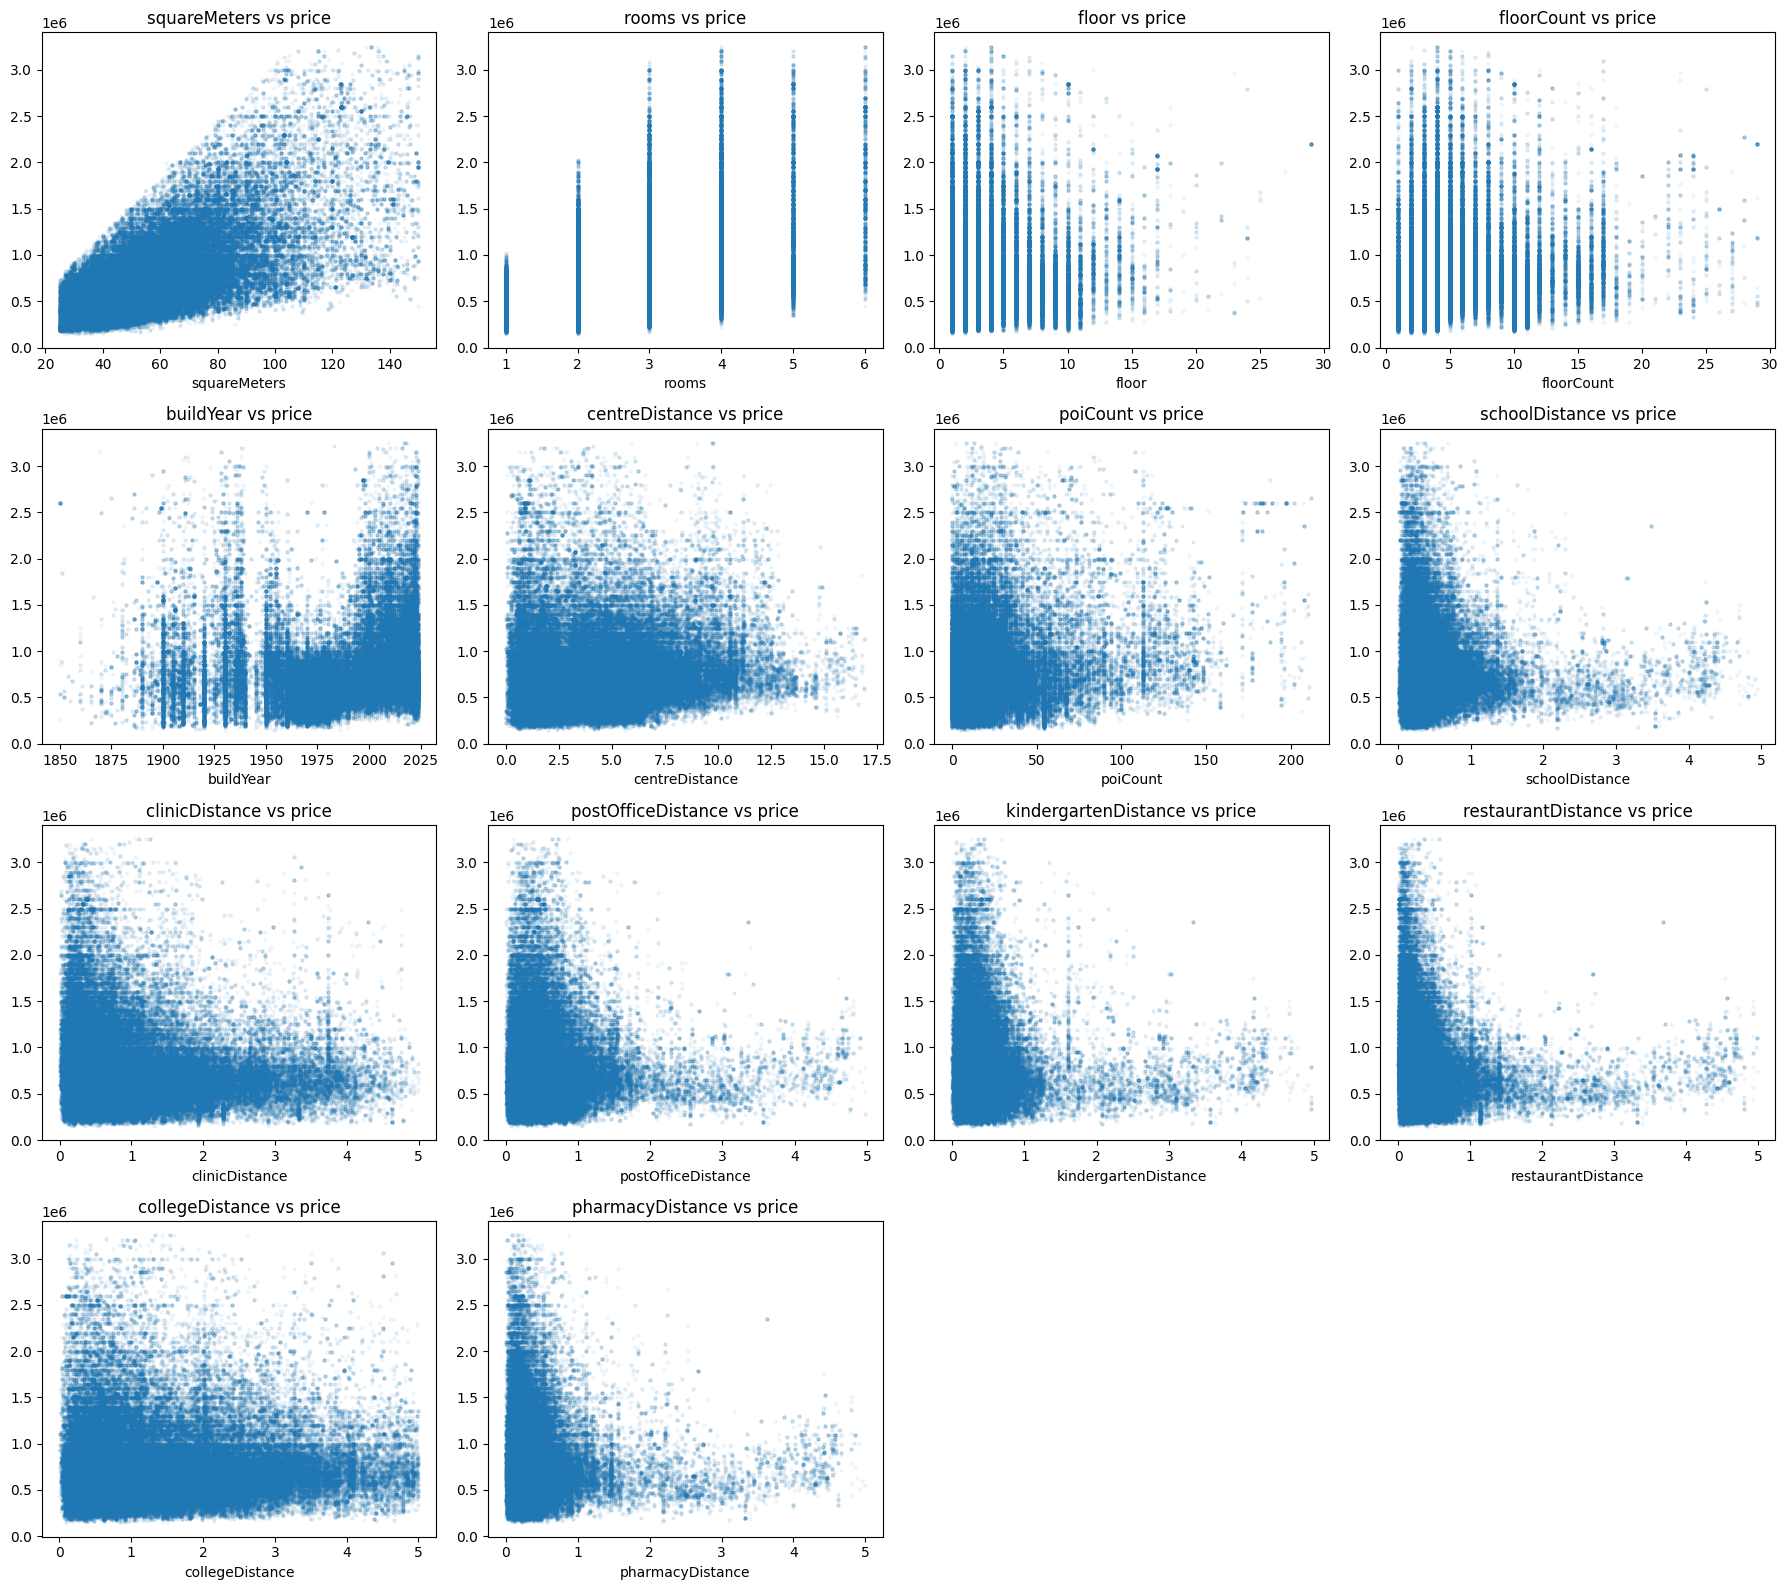

In [5]:
numeric_cols = ['squareMeters', 'rooms', 'floor', 'floorCount', 'buildYear',
                'centreDistance', 'poiCount', 'schoolDistance', 'clinicDistance',
                'postOfficeDistance', 'kindergartenDistance', 'restaurantDistance',
                'collegeDistance', 'pharmacyDistance']

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].scatter(df[col], df['price'], alpha=0.05, s=5)
    axes[i].set_title(f'{col} vs price')
    axes[i].set_xlabel(col)
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.savefig('img/numeric_vs_price.png', dpi=100)
plt.show()

In [6]:
corr = df[numeric_cols + ['price']].corr()['price'].sort_values(ascending=False)
print(corr)

price                   1.000000
squareMeters            0.638238
rooms                   0.495022
poiCount                0.185389
buildYear               0.141382
centreDistance          0.089407
floorCount              0.032559
floor                   0.023562
schoolDistance         -0.000780
postOfficeDistance     -0.012238
pharmacyDistance       -0.014332
collegeDistance        -0.014619
kindergartenDistance   -0.016732
restaurantDistance     -0.106680
clinicDistance         -0.107634
Name: price, dtype: float64


## 5. Correlation matrix (numeric features)

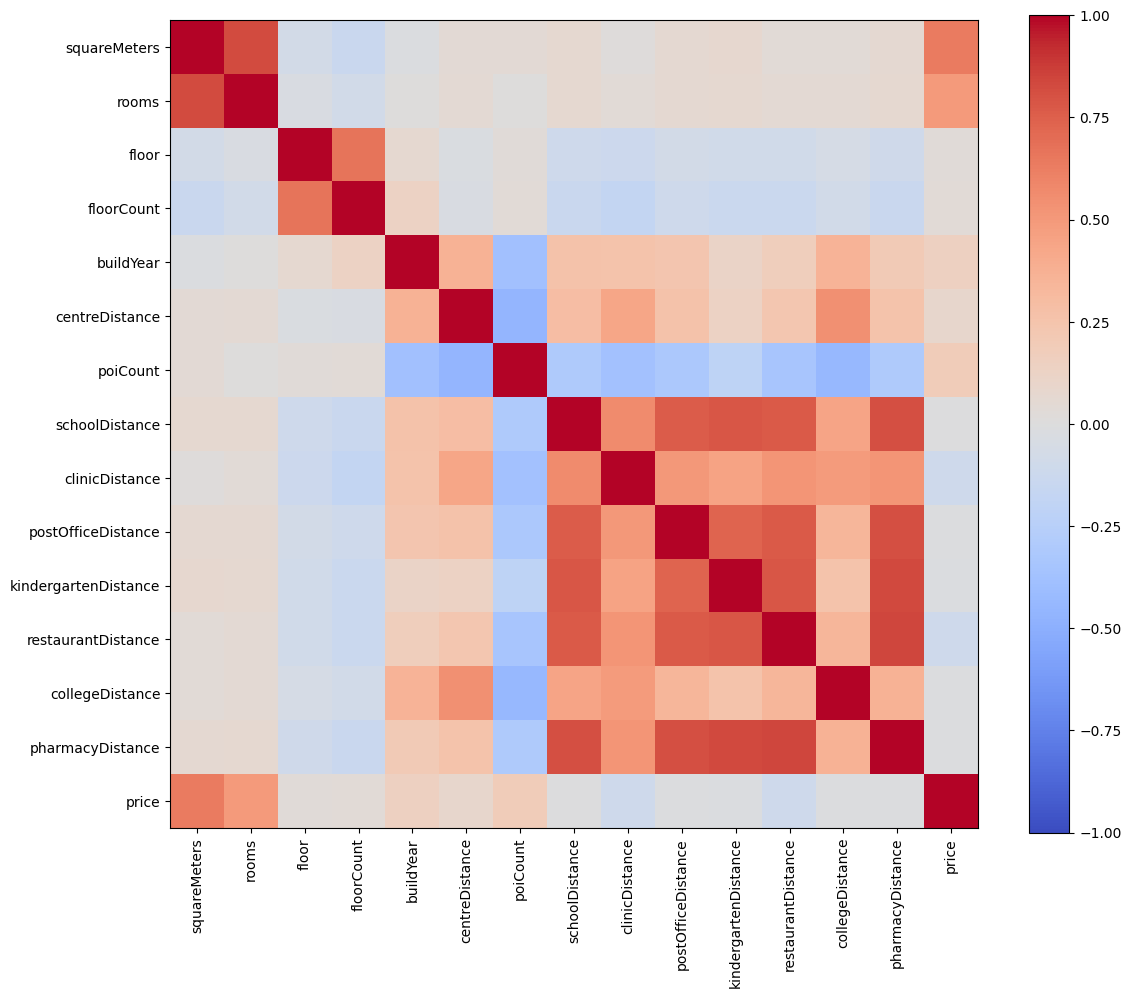

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[numeric_cols + ['price']].corr()
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)
plt.colorbar(im)
plt.tight_layout()
plt.savefig('img/correlation_matrix.png', dpi=100)
plt.show()

## 6. Binary / boolean amenities vs. price

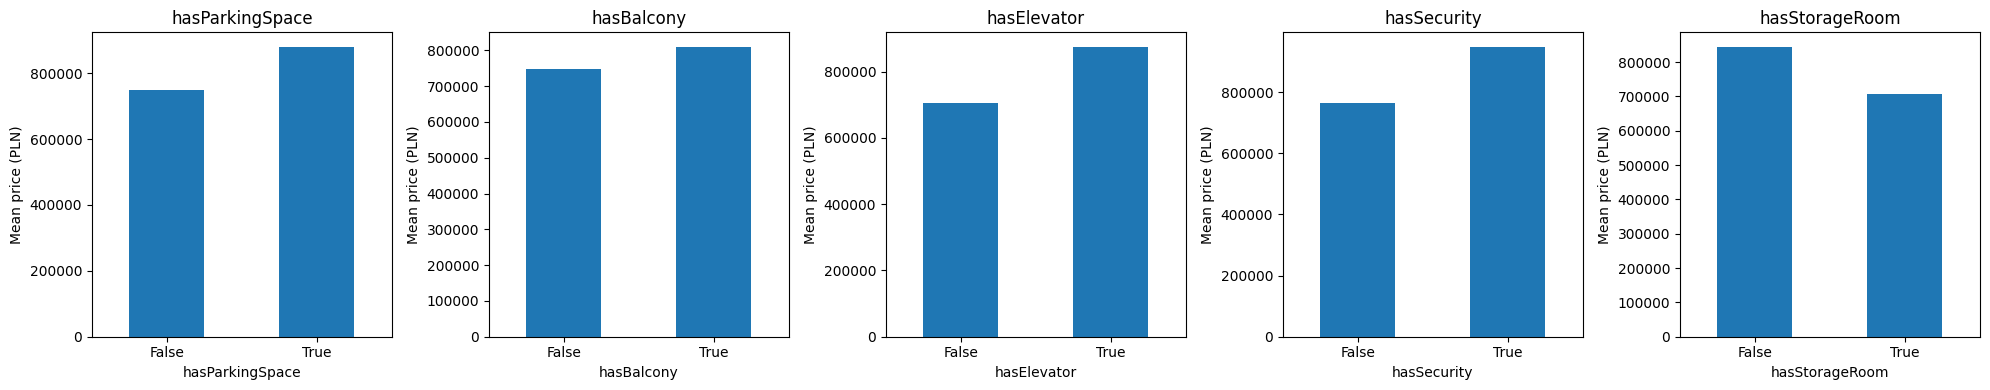

In [8]:
bool_cols = ['hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity', 'hasStorageRoom']

fig, axes = plt.subplots(1, len(bool_cols), figsize=(20, 4))
for i, col in enumerate(bool_cols):
    grouped = df.groupby(col)['price'].mean()
    grouped.plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('Mean price (PLN)')
    axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('img/binary_features_price.png', dpi=100)
plt.show()

## 7. Categorical features vs. price

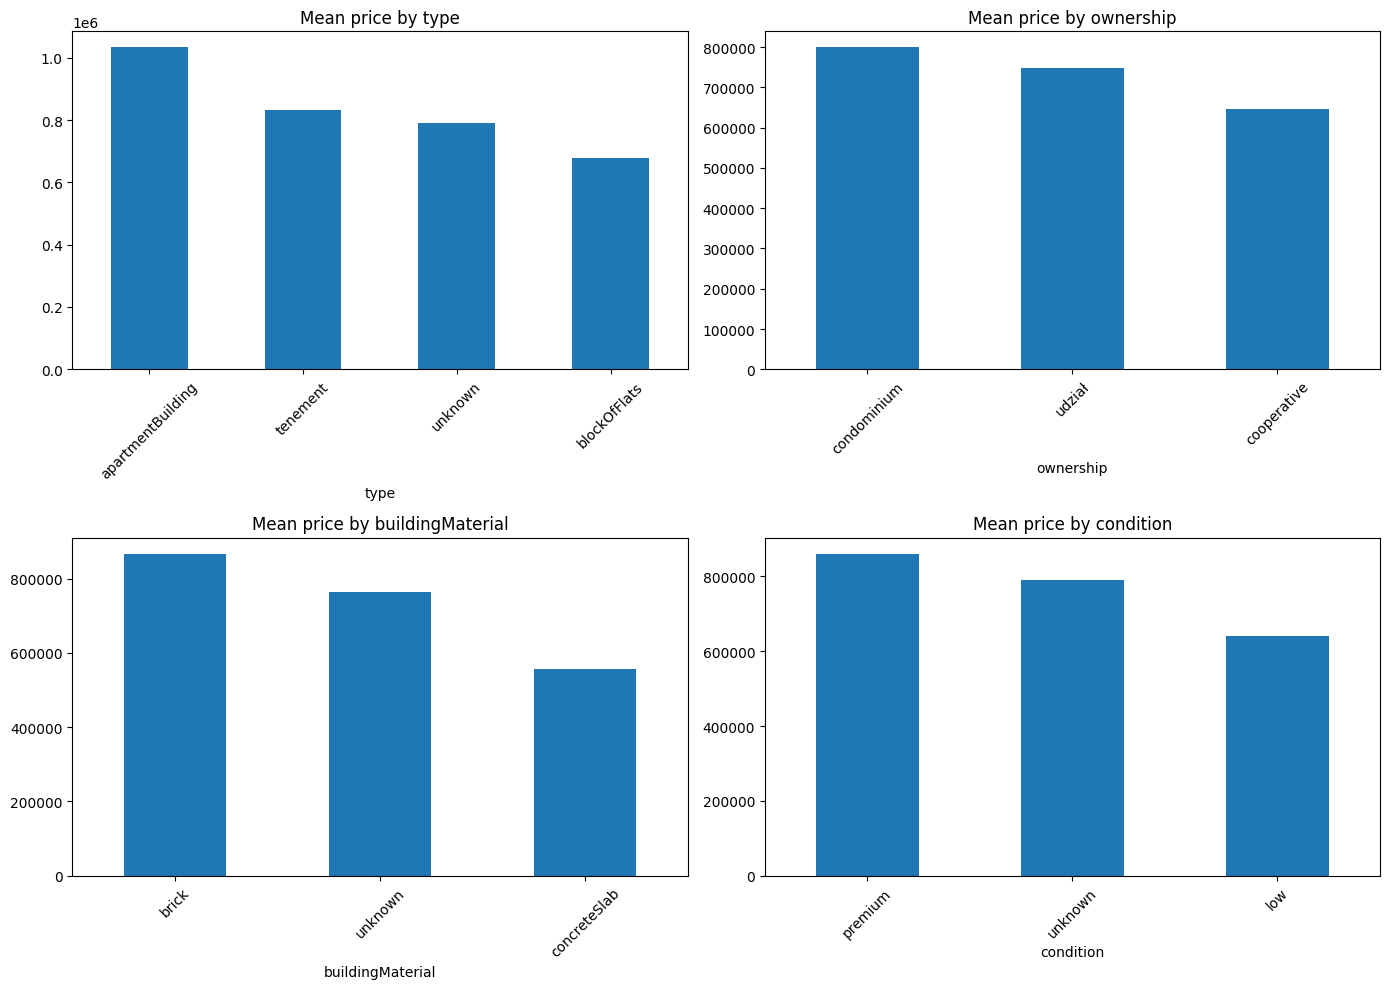

In [9]:
cat_cols = ['type', 'ownership', 'buildingMaterial', 'condition']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    grouped = df.groupby(col)['price'].mean().sort_values(ascending=False)
    grouped.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Mean price by {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('img/categorical_features_price.png', dpi=100)
plt.show()

**Note:** `unknown` categories (from filled-in missing values in Notebook 1) appear here as their own bar — worth watching whether `unknown` behaves like a distinct price tier or just tracks the overall average. If it tracks the average, that's a good sign missingness isn't informative on its own.

## 8. Temporal price trend — new to this dataset vs. the old single-snapshot project

                  median           mean  count
snapshot_month                                
2023-08         620000.0  692102.938674  18638
2023-09         639000.0  707800.790699  16622
2023-10         656700.0  722808.458736  16249
2023-11         679000.0  739101.332470  15821
2023-12         716872.0  812668.742768  16005
2024-01         720000.0  816188.936549  15051
2024-02         720000.0  821747.784158  15882
2024-03         729000.0  827167.495872  16837
2024-04         720000.0  822704.538040  18783
2024-05         720985.0  826429.257550  19802
2024-06         720735.0  824030.228978  21168


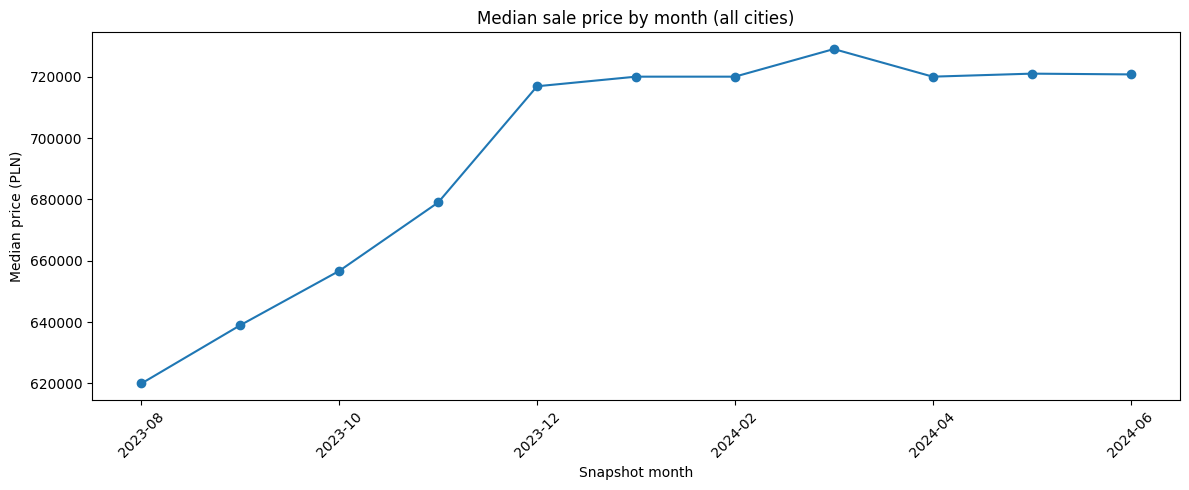

In [10]:
monthly = df.groupby('snapshot_month')['price'].agg(['median', 'mean', 'count']).sort_index()
print(monthly)

fig, ax = plt.subplots(figsize=(12, 5))
monthly['median'].plot(marker='o', ax=ax)
ax.set_title('Median sale price by month (all cities)')
ax.set_ylabel('Median price (PLN)')
ax.set_xlabel('Snapshot month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('img/price_trend_over_time.png', dpi=100)
plt.show()

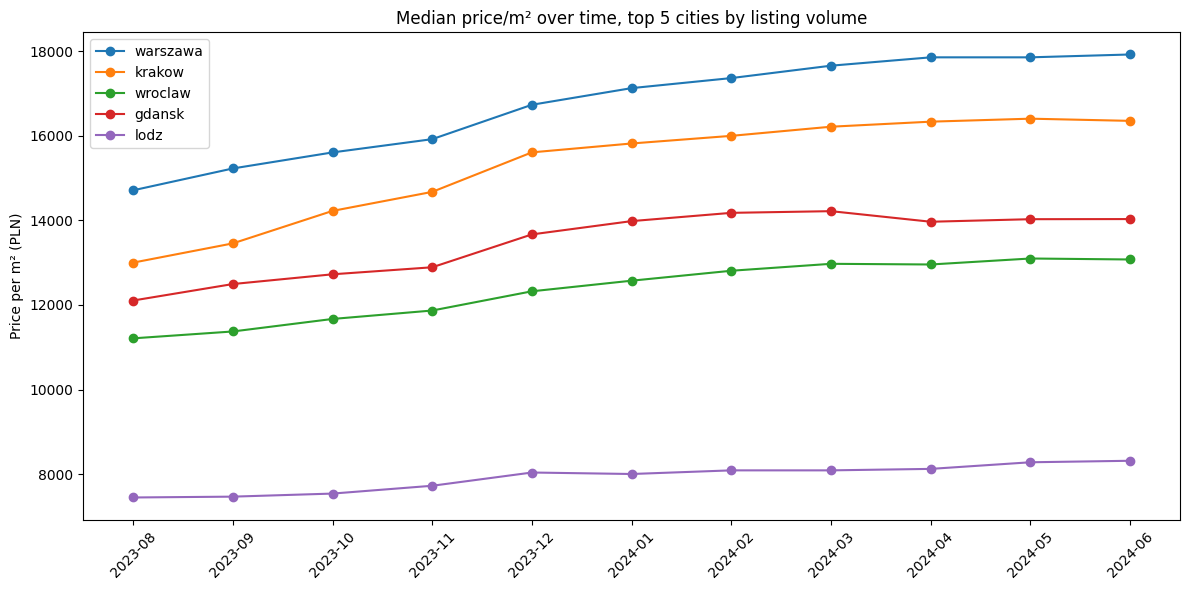

In [11]:
# Same trend, split by a few major cities to see if the trend is uniform or city-specific
top_cities = df['city'].value_counts().head(5).index

fig, ax = plt.subplots(figsize=(12, 6))
for city in top_cities:
    city_monthly = df[df['city'] == city].groupby('snapshot_month')['price_per_sqm'].median()
    ax.plot(city_monthly.index, city_monthly.values, marker='o', label=city)
ax.set_title('Median price/m² over time, top 5 cities by listing volume')
ax.set_ylabel('Price per m² (PLN)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('img/price_trend_by_city.png', dpi=100)
plt.show()

## Key EDA takeaways

- **Price is right-skewed**, as expected — log transform will likely help modeling, as it did in the original project.
- **City is a dominant driver** — the gap between the most and least expensive cities is large even after normalizing to price/m².
- **`squareMeters` and `centreDistance`** show the clearest linear-ish relationships with price, echoing the original project's finding that size and location dominate.
- **Temporal trend is visible** month-over-month — this is the signal Option B (keeping all snapshots) was chosen to capture, and it did not exist in the original single-snapshot project.
- Binary amenities show smaller but real average price differences — similar magnitude to what the original project found for parking/seller type.

Next: `02_Model.ipynb` — feature engineering, grouped train/test split (by `id`, per the leakage concern raised during wrangling), and model comparison across GBR, LightGBM, CatBoost, and ensembles.